# Homework07

Some exercises with `matplotlib` plotting, and `pandas` `DataFrame`.

## Goals

- Get familiar with `matplotlib` graphs and functions
- Use graphs and maths to calculate and communicate statistical properties of data
- Get familiar with the `DataFrame` object and its functionalities
- Experiment with `DataFrame` filtering and searching

## Setup

Run the following $2$ cells to import helper functions, files and libraries:

In [1]:
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/wines.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/spotify_tracks.csv -P ./data

In [2]:
import csv
import matplotlib.pyplot as plt
import pandas as pd

## Choose Your Own Path

### This assignment has $2$ exercises. You only have to do $1$.<br>Take a look at both and pick the one you find more interesting.<br>(The second one is longer, and a bit more challenging)

## Exercise 01: Song Popularity

What qualities would you give songs to help them be popular ?

Let's use the spotify dataset to try to find trends, patterns and characteristics that are common of popular songs.

There are a couple of ways of doing this, but the first thing to do is load the `CSV` file into a `DataFrame`:

In [6]:
# TODO: load ./data/spotify_tracks.csv into a DataFrame
spotify_df = pd.read_csv("./data/spotify_tracks.csv").drop(columns=["Unnamed: 0"])
spotify_df
# TODO: take a quick look at the table, column names, etc
print(spotify_df.columns)

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')


In [7]:
spotify_df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


### Separate Features

It will help to create a separate `DataFrame` that only has numeric information for the songs.

The `columns` variable of our `DataFrame` will list all of the columns in our dataset, and the `dtypes` variable will list the type of data that's in each.

We want columns that hold `int`, `float` and `bool` data, while skipping the ones that hold `object` (text).

Once we have a list of the target columns, we can get them from the whole `DataFrame` by indexing with the actual list of columns:

```py
num_data_df = data_df[list_of_columns]
```

There should be about $15$ columns, or a little less if you skip the `bool` values.

In [14]:
# TODO: get list of column names of numeric data
spotify_df.dtypes



track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [17]:
# TODO: use list to create subset DataFrame
num_data_df = spotify_df[["popularity", "duration_ms", "danceability", "energy", "key", "loudness" , "mode" , "speechiness" ,"acousticness", "instrumentalness", "liveness" , "valence" , "tempo" , "time_signature" ]]
num_data_df

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


### Math ? Graph ? Both ?

Using a combination of math and graphs, which of these numeric features contribute to a song being popular?

Or, another way to ask this: what do popular songs have in common ?

#### Stats

Remember from lecture that we looked at a few mathematical and statistical operations that help us summarize our data.

Average values tell us the most likely value of a column/feature, while standard deviation tells us how much all of the values differ from the average. Another meaningful calculation here is the correlation amongst our features. This measure tells us how much $2$ properties are linked together: high positive correlation means that if one feature goes up, the other also goes up; high negative correlation means that one feature goes down as the other goes up; correlation near $0$ means the two features are not related. Even when not "highly related", correlation values can still tell us something about the relationships in our data.

These calculations are easily accessible from a `DataFrame`, using its `mean()`, `std()` and `corr()` functions.

#### Graphs

We also saw how to plot $\text{2D}$ graphs using the `matplotlib` package. The `plt.scatter()` function can be helpful here. Given the amount of data in this dataset, adjust the size of the markers and their opacity will help.

We can use a `for` loop together with our list of columns to plot the relationship between ***ALL*** of the features and `popularity`. We might not see straight lines in the graphs, but there are patterns. For most of the comparisons, you'll see specific clusters/groups of values that indicate that a certain value is more common than the other.

#### Both

Either graphs or maths is enough to get some initial sense for the data and its trends/patterns.

A more complete strategy could involve both: correlation analysis followed by graphing the most correlated features.

Another idea is to filter the dataset and only look at trends for very popular and very unpopular songs. Follow the patterns in one group and avoid any patterns in the other.

popularity          33.238535
danceability         0.566800
energy               0.641383
tempo              122.147837
key                  5.309140
duration_ms     228029.153114
dtype: float64

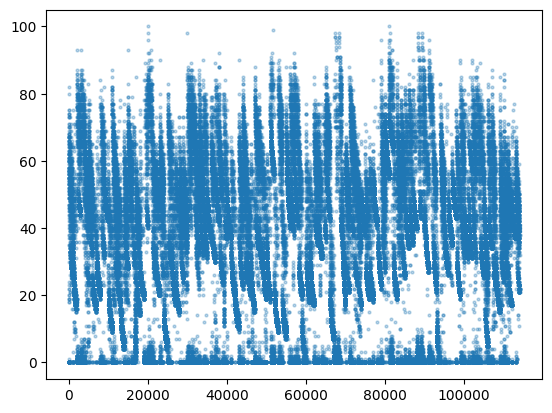

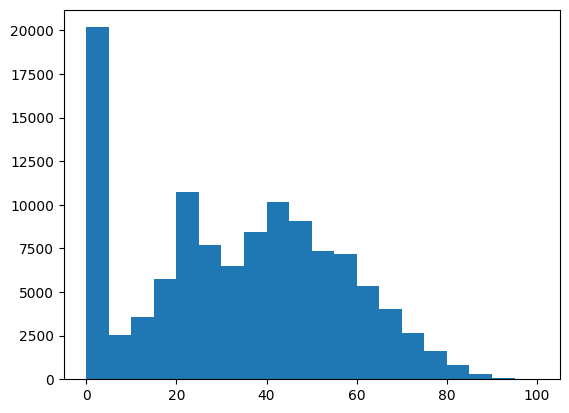

In [39]:
# TODO: Exploratory data analysis for features that correlate with song popularity
display(num_data_df[["popularity", "danceability" , "energy", "tempo", "key", "duration_ms"]].mean())

plt.plot(spotify_df["popularity"], marker="o", linestyle="", markersize=2, alpha=.3)
plt.show()
plt.hist(spotify_df["popularity"], bins=20)
plt.show()


# TODO: by correlation
# OR
# TODO: by graphing
# OR
# TODO: both
# OR
# TODO: by filtering first


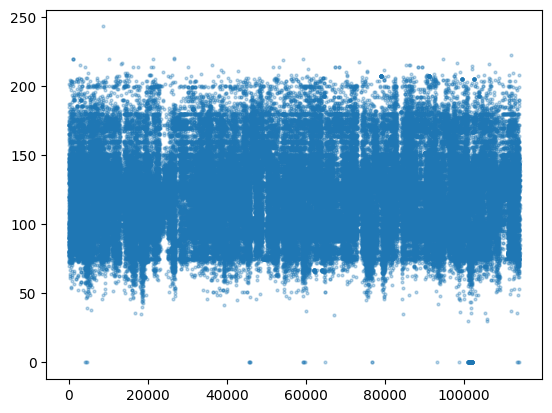

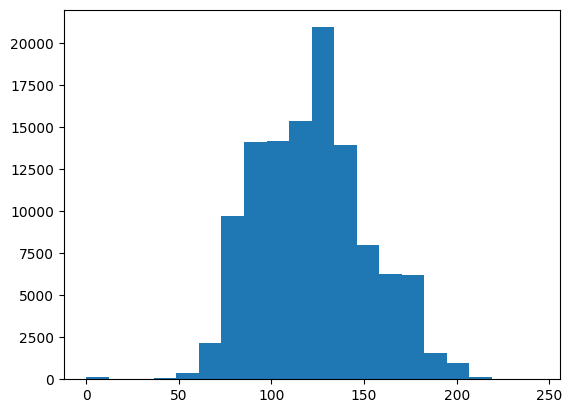

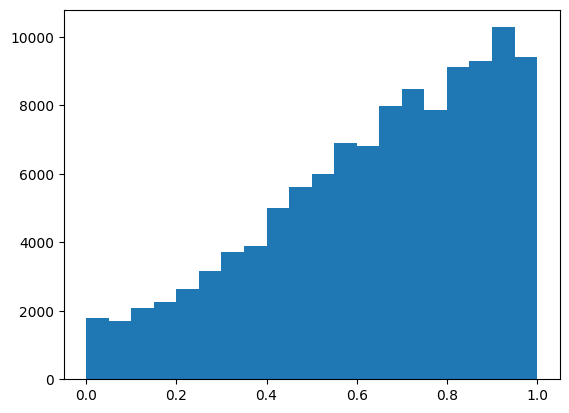

In [ ]:
plt.plot(num_data_df["tempo"], marker="o", linestyle="", markersize=2, alpha=.3)
plt.show()
plt.hist(num_data_df["tempo"], bins=20)
plt.show()

#plot energy column 
plt.hist(num_data_df["energy"],bins=20)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

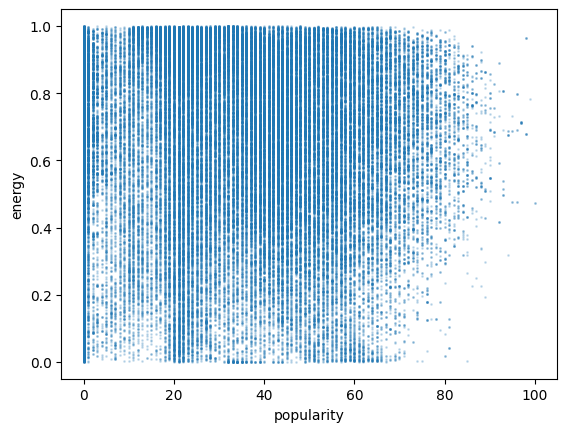

In [26]:
plt.plot(num_data_df["popularity"], num_data_df["energy"], linestyle="", marker="o", markersize=1, alpha=0.2)
plt.xlabel("popularity")
plt.ylabel("energy")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

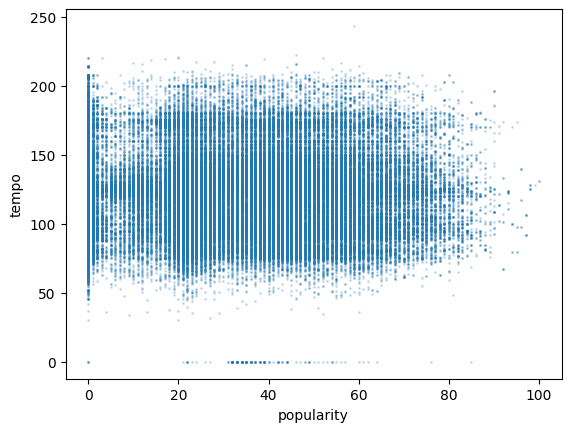

In [27]:
plt.plot(num_data_df["popularity"], num_data_df["tempo"], linestyle="", marker="o", markersize=1, alpha=0.2)
plt.xlabel("popularity")
plt.ylabel("tempo")
plt.show

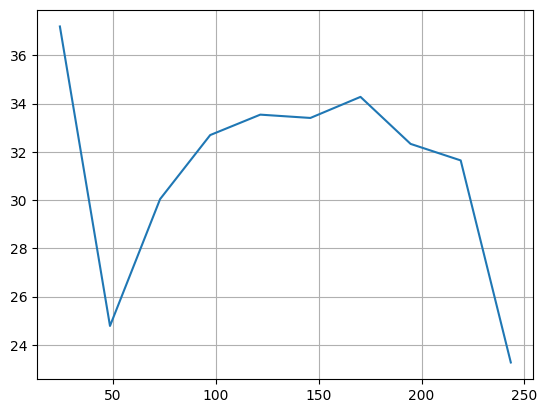

In [45]:
popularity_tempo_df=spotify_df[["popularity", "tempo"]].copy()

bin_ids, bin_tempo = pd.cut(popularity_tempo_df["tempo"], bins=10, labels=False, retbins=True)

popularity_tempo_df["tempo_bin"] = bin_ids

pop_by_bin = popularity_tempo_df.groupby("tempo_bin")["popularity"].mean()

# TODO: plot
plt.plot(bin_tempo[1:], pop_by_bin)
plt.grid()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

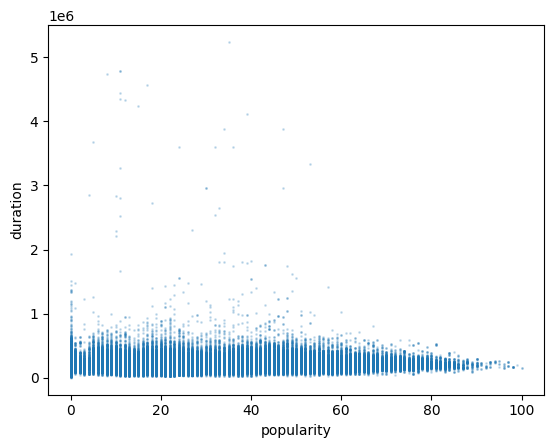

In [30]:
plt.plot(num_data_df["popularity"], num_data_df["duration_ms"], linestyle="", marker="o", markersize=1, alpha=0.2)
plt.xlabel("popularity")
plt.ylabel("duration")
plt.show

In [33]:
energy_popularity_df= num_data_df[
  (num_data_df["energy"] > 0.65) &
  (num_data_df["popularity"] > 34)
]
energy_popularity_df

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
14,56,188133,0.755,0.780,2,-6.084,1,0.0327,0.124000,0.000028,0.121,0.387,120.004,4
51,61,232360,0.373,0.914,0,-4.185,1,0.0565,0.076000,0.000000,0.669,0.560,168.210,4
52,60,241119,0.494,0.652,6,-5.863,0,0.0314,0.075400,0.002560,0.125,0.298,137.018,4
55,62,286865,0.536,0.890,1,-5.222,1,0.0375,0.078000,0.020200,0.131,0.273,121.974,4
61,62,244320,0.430,0.791,6,-5.419,0,0.0302,0.072600,0.019300,0.110,0.217,171.864,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113981,39,289179,0.498,0.957,1,-5.807,0,0.1620,0.005270,0.000000,0.477,0.205,128.028,4
113987,40,246306,0.470,0.938,11,-4.722,0,0.1050,0.000529,0.000000,0.251,0.453,128.002,4
113988,38,462397,0.296,0.762,2,-5.696,1,0.0548,0.072400,0.000003,0.374,0.146,139.051,4
113992,38,312566,0.475,0.860,10,-4.722,1,0.0421,0.006500,0.000002,0.246,0.427,113.949,4


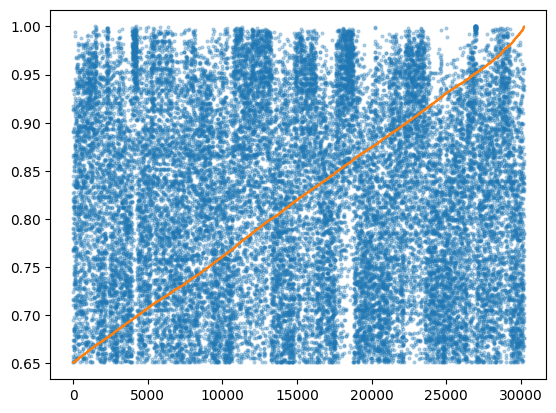

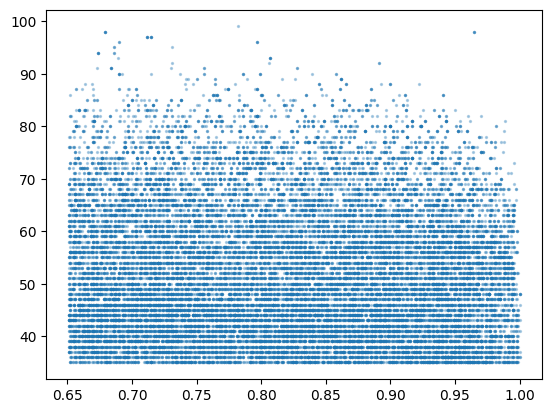

In [34]:
plt.plot(energy_popularity_df["energy"].values, linestyle="", marker="o", markersize=2, alpha=.3)
plt.plot(sorted(energy_popularity_df["energy"]))
plt.show()

plt.scatter(energy_popularity_df["energy"], energy_popularity_df["popularity"], s=2, alpha=.3)
plt.show()

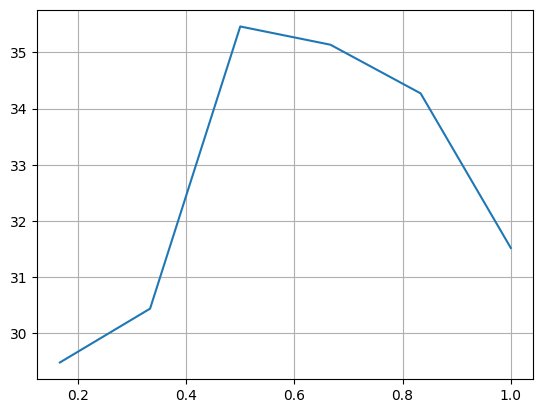

In [51]:
popularity_energy_df=spotify_df[["popularity", "energy"]].copy()

bin_ids, bin_energy = pd.cut(popularity_energy_df["energy"], bins=6, labels=False, retbins=True)

popularity_energy_df["energy_bin"] = bin_ids

pop_by_bin = popularity_energy_df.groupby("energy_bin")["popularity"].mean()

# TODO: plot
plt.plot(bin_energy[1:], pop_by_bin)
plt.grid()
plt.show()


In [42]:
tempo_popularity_df= num_data_df[
  (num_data_df["tempo"] > 100) &
  (num_data_df["popularity"] > 34)
]
tempo_popularity_df

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.905000,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.469000,0.000000,0.0829,0.1670,119.949,4
6,74,229400,0.407,0.1470,2,-8.822,1,0.0355,0.857000,0.000003,0.0913,0.0765,141.284,3
7,80,242946,0.703,0.4440,11,-9.331,1,0.0417,0.559000,0.000000,0.0973,0.7120,150.960,4
8,74,189613,0.625,0.4140,0,-8.700,1,0.0369,0.294000,0.000000,0.1510,0.6690,130.088,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113987,40,246306,0.470,0.9380,11,-4.722,0,0.1050,0.000529,0.000000,0.2510,0.4530,128.002,4
113988,38,462397,0.296,0.7620,2,-5.696,1,0.0548,0.072400,0.000003,0.3740,0.1460,139.051,4
113992,38,312566,0.475,0.8600,10,-4.722,1,0.0421,0.006500,0.000002,0.2460,0.4270,113.949,4
113993,39,256026,0.505,0.6870,10,-4.375,1,0.0287,0.084100,0.000000,0.1880,0.3820,104.083,3


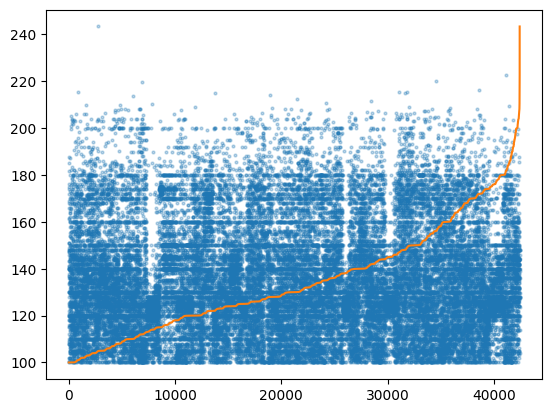

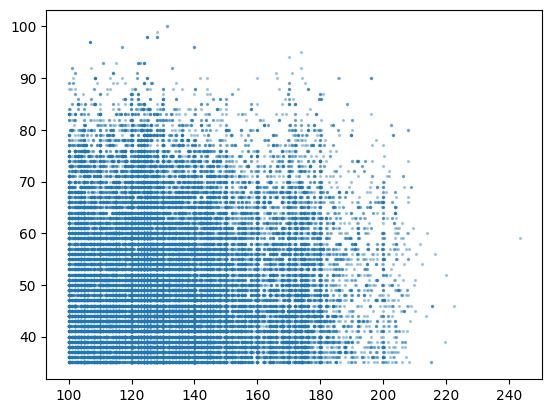

In [43]:
plt.plot(tempo_popularity_df["tempo"].values, linestyle="", marker="o", markersize=2, alpha=.3)
plt.plot(sorted(tempo_popularity_df["tempo"]))
plt.show()

plt.scatter(tempo_popularity_df["tempo"], tempo_popularity_df["popularity"], s=2, alpha=.3)
plt.show()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
5,58,214240,0.688,0.4810,6,-8.807,1,0.1050,0.289000,0.000000,0.1890,0.6660,98.017,4
7,80,242946,0.703,0.4440,11,-9.331,1,0.0417,0.559000,0.000000,0.0973,0.7120,150.960,4
10,74,244800,0.627,0.3630,8,-8.127,1,0.0291,0.279000,0.000000,0.0928,0.3010,99.905,4
12,52,198712,0.489,0.3140,7,-9.245,0,0.0331,0.749000,0.000000,0.1130,0.6070,124.234,4
17,54,169728,0.795,0.0841,10,-18.090,0,0.0461,0.742000,0.000012,0.0853,0.6090,91.803,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113983,37,377697,0.363,0.4620,7,-8.232,1,0.0284,0.008870,0.000009,0.7060,0.0687,80.003,4
113987,40,246306,0.470,0.9380,11,-4.722,0,0.1050,0.000529,0.000000,0.2510,0.4530,128.002,4
113992,38,312566,0.475,0.8600,10,-4.722,1,0.0421,0.006500,0.000002,0.2460,0.4270,113.949,4
113993,39,256026,0.505,0.6870,10,-4.375,1,0.0287,0.084100,0.000000,0.1880,0.3820,104.083,3


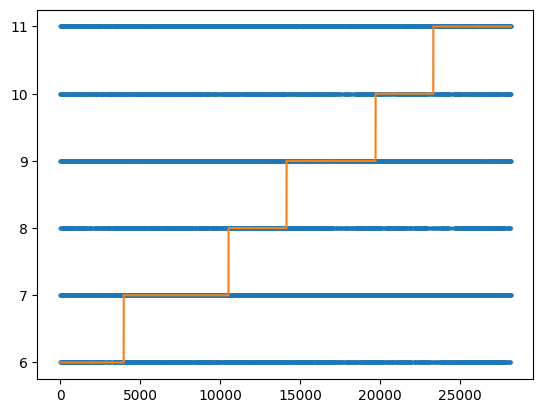

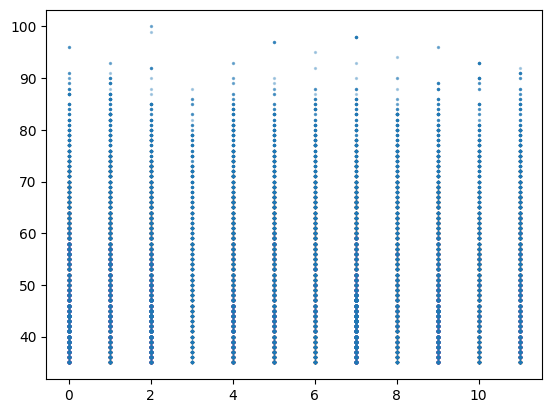

### Findings

<span style="color:hotpink;">
What did you find ? What are some common characteristics of popular songs ?
</span>

<span style="color:hotpink;">
EDIT THIS CELL WITH ANSWER
</span>

## Exercise 02: Navigating Data

In this exercise we're going to explore the search and filter capabilities of the `DataFrame` to connect a couple of datasets and solve a mystery.

This is based on the [SQL Murder Mystery](https://mystery.knightlab.com/) exercise, but using different datasets created specifically for `pandas` and `DataFrame` objects.

Run the following $2$ cells to load the data and libraries we'll need.

In [ ]:
!wget -qO- https://github.com/PSAM-5005-2026S-A/5005-utils/releases/latest/download/mystery.tar.gz | tar xz

In [ ]:
import pandas as pd
from Homework07_utils import Homework07_utils

### The Data

We'll be working with data from $6$ different sources:

- `report.csv`: Database of reported crimes
- `testimony.csv`: Database of testimony taken by police
- `license.csv`: DMV data
- `person.csv`: Names, addresses, social security numbers
- `update.csv`: List of social media updates
- `cringe.csv`: Membership information for _Cringe Gym_

### The Functions

Loading these into `DataFrame` objects will help us organize, navigate and connect the data.

We can perform basic searches by indexing a `DataFrame` with boolean expressions.

- This returna all rows with a value of `good` for the `rating` column:<br>
  `df[df["rating"] == "good"]`
- This returna all rows with a `grade` greater than $70$:<br>
  `df[df["grade"] > 70]`
- We can chain multiple conditions with boolean operator. To get all rows of `mammals` that weight more than $50$ $\text{kg}$:<br>
  `df[(df["class"] == "mammalia") & (df["weight"] > 50)]` (note the parenthesis)
- [More examples and documentation](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing)


In addition to boolean indexing, the following functions can help us navigate and filter `DataFrame` objects efficiently:

- [`sort_values()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html): for sorting a `DataFrame` by column values
- [`str.contains()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html): for checking if a string contains a substring
- [`str.startswith()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.startswith.html): for checking if a string starts with a specific pattern
- [`isin()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html): for checking if a value matches one of a few choices
- [`isna()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.isna.html): for checking if a values is empty/null
- [`apply(axis=1)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html): applies function to all rows of a `DataFrame`

### Loading Data

Let's get this out of the way and just load all `csv` datasets at once.

Take a look at their column names and a few rows to see what kind of data is in each.

In [ ]:
gym_df = pd.read_csv("./data/csv/mystery/cringe.csv")
dmv_df = pd.read_csv("./data/csv/mystery/license.csv")
person_df = pd.read_csv("./data/csv/mystery/person.csv")
report_df = pd.read_csv("./data/csv/mystery/report.csv")
testimony_df = pd.read_csv("./data/csv/mystery/testimony.csv")
social_df = pd.read_csv("./data/csv/mystery/update.csv", keep_default_na=False)

In [ ]:
# TODO: Look at datasets/DataFrames

### Getting Started

We're going to see if we can help solve the latest crime reported in the city.

Let's start by finding information about the crime in the `report` database.

We're looking for the most recent crime reported.

In [ ]:
# TODO: find most recent crime reported, look at the full description and get the name of the victim

### Check Answer

Run the following cell with the name of the victim.

In [ ]:
# TODO: put name of victim in variable
victim_name = "HERE"
Homework07_utils.check("victim", victim_name)

### Witness Testimony

Let's follow the thread from the crime description and find the testimony from the witnesses.

We'll use the `person` and `testimony` datasets together with the info we got previously from the `report` `DataFrame`.

In [ ]:
# TODO: find testimony of people who live across the street from crime

# TODO: probably find the names of the people who live across the street from the crime first

# TODO: then cross reference their data with the testimony dataset

### Check Answer

We can add the witnesses names to a list and check our answer with the following cell.

In [ ]:
# TODO: put name of victim in variable
witness_names = ["Witness 0", "Witness 1"]
Homework07_utils.check("witnesses", witness_names)

In [ ]:
# TODO: put name of victim in variable
witness_names = ["Witness 0", "Witness 1"]
Homework07_utils.check("witnesses", witness_names, True)

print()
witness_names = ["Hope Arzabala", "Ressie Razze"]
Homework07_utils.check("witnesses", witness_names)

### Read Full Testimony and Follow the Clues

We can use the `gym` `DataFrame` and info from one of the testimonies to get an initial list of suspects.

In parallel, we can look for relevant posts in the `social` dataset. We can start by searching for potential email addresses for the other witness... it's common to use our first name or surname when we create email accounts...

In [ ]:
# TODO: get list of potential suspects from gym data

# TODO: find posts from the other witness in the social dataset

### Check Answer

Check the found clues below.

In [ ]:
# TODO: put name of potential gym suspects here
potential_suspects_gym = ["list", "of", "all", "suspects", "from", "gym"]
Homework07_utils.check("gym", potential_suspects_gym)

In [ ]:
# TODO: put witness's email address here
wit_email_address = "someone@somewhere.com"
Homework07_utils.check("email", wit_email_address)

### Find Visual Evidence

Once we have the email address for the witness, we can search for relevant posts with images that were created around the time of the crime.

The images are stored on the `DataFrame` as [$\text{Base}64$-encoded](https://en.wikipedia.org/wiki/Base64) text. This is a common technique for transmitting or storing different types of information when the available channels only support text.

Don't worry about decoding the image. Once you've found something using the other columns of the dataset, you can check the answer and get the decoded image using the `Homework07_utils.check()` function.

In [ ]:
# TODO: find relevant posts with images using the email, status and datetime columns

In [ ]:
# TODO: find relevant posts with images using the email, status and datetime columns
all_posts = social_df[social_df["email"] == wit_email]
all_posts

image_posts = all_posts[all_posts["image"] != ""]
image_posts

relevant_image_posts = image_posts[(image_posts["datetime"].str.startswith("2026")) &
                                    image_posts["status"].str.contains("package")]
relevant_image_posts

### Check Answer

Check and visualize the image below.

In [ ]:
# TODO: put the encoded image text in the following variable
encoded_image = social_df.iloc[5]["image"]
Homework07_utils.check("image", encoded_image)

### Follow the Evidence

Now we can use the image we just found and the `dmv` dataset to narrow down the list of potential suspects from the gym.

In order to make the connection between `dmv` and `gym` datasets we need people's names. The `license_id` field can be _transformed_/_translated_ into a name using the `person` dataset one more time. The `apply()` function can help here.

The overall process will be:
- find people in the `dmv` dataset related to the image found in the previous step
- get their `name` from their `license_id`
- see if any of them are also in the list of suspects from the gym.

We have a couple of options to do the last step. We can use a `for` loop and iterate over the `gym` names while checking if any of them are in the list of names from the `dmv`. Or, we can do the opposite and iterate over the `dmv` names while checking if any of them are in the `gym` list.

OR, we can use `set` objects to find the _intersection_ between the $2$ lists. These `set` objects are like lists, but they only keep unique items.

```py
mylist = [0,2,2,4,4,4,6,7,8]
myset = set(mylist)
print(myset)
>>> {0, 2, 4, 6, 7, 8}
```

SO, they are great for doing _Venn diagram_ type of operations:

<div style="overflow:hidden;">
  <img style="margin-top:-40px;" src="https://media.geeksforgeeks.org/wp-content/uploads/20240711100807/Set-operations.png" width=600>
</div>

`set` [documentation](https://docs.python.org/3.10/library/stdtypes.html#set) and [examples](https://www.w3schools.com/python/python_sets.asp).

### Check Answer

Check the name of the suspect here.

In [ ]:
# TODO: put the name of the suspect here
suspect_name = "HERE"
Homework07_utils.check("suspect", suspect_name)